In [11]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import statsmodels.graphics.api as smg
from numpy import percentile
from numpy.random import rand
from sklearn.preprocessing import LabelEncoder
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

In [12]:
#Read the data as dataframe
df = pd.read_csv("C:\AIML\Assessment\R2\External Assessment\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
#Q3.a - Shape of the data
df.shape

(1338, 7)

In [14]:
#Q3.b - Data type of each attribute
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [19]:
#Q3.c - Checking the presence of missing values.
#Since there is no missing value in the dataframe, values are retuned as '0'
missing_values=df.columns[df.isnull().any()]
df[missing_values].isnull().sum()

Series([], dtype: float64)

In [20]:
#Q3.d - 5 point summary of numerical attributes
#By descrbing the dataframe - we can infer 5 point - min, max, Q1, Q3, median
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [21]:
#Q3.d - 5 point summary of numerical attributes
#Another way to find the 5 point summary for numerical data

five_pt_age = np.percentile(df['age'],[0,25,50,75,100])
print("5 point summary of column Age:- min: %3f, Q1: %3f, median: %3f, Q3: %3f, max: %3f " %(five_pt_age[0], five_pt_age[1],five_pt_age[2], five_pt_age[3],five_pt_age[4]) )

five_pt_bmi = np.percentile(df['bmi'],[0,25,50,75,100])
print("5 point summary of column bmi:- min: %3f, Q1: %3f, median: %3f, Q3: %3f, max: %3f " %(five_pt_bmi[0], five_pt_bmi[1],five_pt_bmi[2], five_pt_bmi[3],five_pt_bmi[4]) )

five_pt_children = np.percentile(df['children'],[0,25,50,75,100])
print("5 point summary of column children:- min: %3f, Q1: %3f, median: %3f, Q3: %3f, max: %3f " %(five_pt_children[0], five_pt_children[1],five_pt_children[2], five_pt_children[3],five_pt_children[4]) )

five_pt_charges = np.percentile(df['charges'],[0,25,50,75,100])
print("5 point summary of column charges:- min: %3f, Q1: %3f, median: %3f, Q3: %3f, max: %3f " %(five_pt_charges[0], five_pt_charges[1],five_pt_charges[2], five_pt_charges[3],five_pt_charges[4]) )


5 point summary of column Age:- min: 18.000000, Q1: 27.000000, median: 39.000000, Q3: 51.000000, max: 64.000000 
5 point summary of column bmi:- min: 15.960000, Q1: 26.296250, median: 30.400000, Q3: 34.693750, max: 53.130000 
5 point summary of column children:- min: 0.000000, Q1: 0.000000, median: 1.000000, Q3: 2.000000, max: 5.000000 
5 point summary of column charges:- min: 1121.873900, Q1: 4740.287150, median: 9382.033000, Q3: 16639.912515, max: 63770.428010 


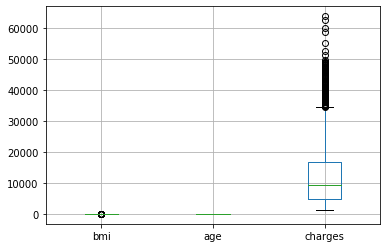

In [22]:
#Q3.e - Distribution of ‘bmi’, ‘age’ and ‘charges’ columns.
df1 = df[['bmi','age','charges']]
df1.boxplot()

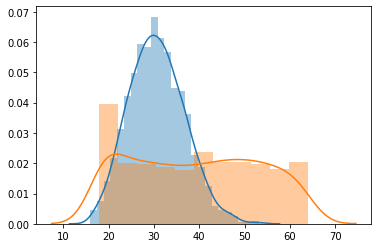

In [23]:
#Q3.e - To find distribution of individual column "bmi", "age"
sns.distplot(df[['bmi']])
sns.distplot(df[['age']])

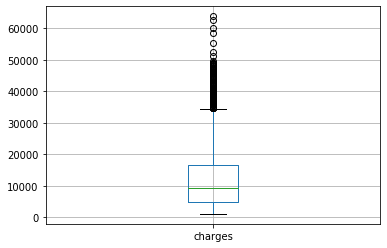

In [24]:
#Q3.e - To find distribution of individual column "charges"
df[['charges']].boxplot()

In [25]:
#Q3.f - Measure of skewness of ‘bmi’, ‘age’ and ‘charges’columns

df.skew(numeric_only  = True)

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

In [26]:
#Q3.f - ##Another approach Using scipy stats - can identify skewness
#All these attributes / features has positive values and hence this is skewed towards right tail.
age = scipy.stats.skew(df['age'])
print("Age: %3f" %age)

bmi = scipy.stats.skew(df['bmi'])
print("Bmi: %3f" %bmi)

children = scipy.stats.skew(df['children'])
print("children: %3f" %children)

charges = scipy.stats.skew(df['charges'])
print("charges: %3f" %charges)

Age: 0.055610
Bmi: 0.283729
children: 0.937328
charges: 1.514180


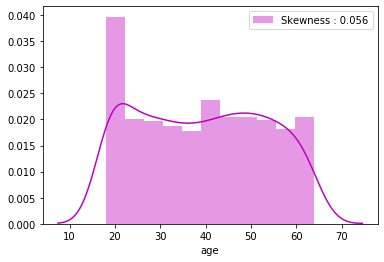

In [27]:
#Q3.f - Measure of skewness of ‘bmi’, ‘age’ and ‘charges’columns - pictorial representation
g = sns.distplot(df['age'], color="m", label="Skewness : %.03f"%(df['age'].skew()))
g = g.legend(loc="best")

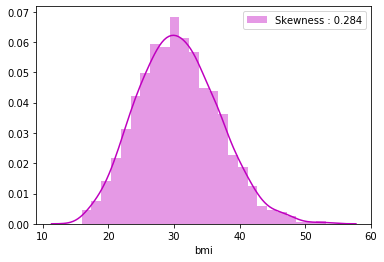

In [28]:
#Q3.f - Measure of skewness of ‘bmi’, ‘age’ and ‘charges’columns - - pictorial representation
g = sns.distplot(df['bmi'], color="m", label="Skewness : %.03f"%(df['bmi'].skew()))
g = g.legend(loc="best")

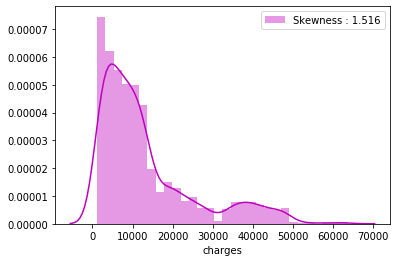

In [29]:
#Q3.f - Measure of skewness of ‘bmi’, ‘age’ and ‘charges’columns - - pictorial representation
g = sns.distplot(df['charges'], color="m", label="Skewness : %.03f"%(df['charges'].skew()))
g = g.legend(loc="best")

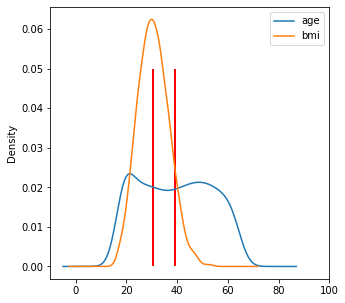

In [30]:
#Q3.f - Measure of skewness of ‘bmi’, ‘age’ and ‘charges’columns
#Plot the skewness in pictorial representation for 'age' and 'bmi'.
#Another way to measure skewness.

def plot_skewness(column1, column2):
        skewed_data = pd.DataFrame(df[[column1,column2]])

        skewed_data.plot(kind="density",
                      figsize=(5,5),
                        xlim=(-10, 100))


        plt.vlines(skewed_data.mean(),     
                   ymin=0, 
                   ymax=0.05,
                   linewidth=2.0,
                   label = 'mean',
                   linestyles = 'dashdot',
                   color = 'blue'
                  )

        plt.vlines(skewed_data.median(),   
                   ymin=0, 
                   ymax=0.05, 
                   linewidth=2.0,
                   label = 'median',
                   color='red')
plot_skewness('age','bmi')

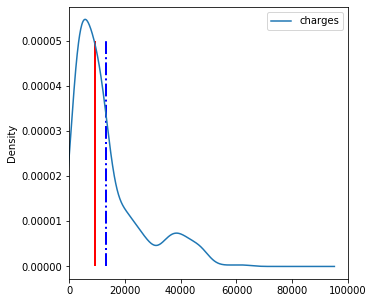

In [31]:
#Q3.f - Measure of skewness of ‘bmi’, ‘age’ and ‘charges’columns
#Plot the skewness in pictorial representation for 'charges'.

def plot_skewness(column):
        skewed_data = pd.DataFrame(df[column])

        skewed_data.plot(kind="density",
                      figsize=(5,5),
                        xlim=(0,100000))


        plt.vlines(skewed_data.mean(),     
                   ymin=0, 
                   ymax=0.00005,
                   linewidth=2.0,
                   label = 'mean',
                   linestyles = 'dashdot',
                   color = 'blue'
                  )

        plt.vlines(skewed_data.median(),   
                   ymin=0, 
                   ymax=0.00005, 
                   linewidth=2.0,
                   label = 'median',
                   color='red')
plot_skewness('charges')

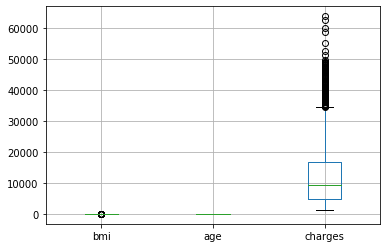

In [32]:
#Q3.g - Checking the presence of outliers in ‘bmi’, ‘age’ and ‘charges' columns
#Pictorial representation of outliers using boxplot.
df[['bmi','age', 'charges']].boxplot()

In [33]:
#Q3.g - Checking the presence of outliers in ‘bmi’, ‘age’ and ‘charges' columns
#using IQR method.
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [34]:
out_iqr(df,'bmi')

The IQR is 8.3975
The lower bound value is 13.7
The upper bound value is 47.290000000000006
Total number of outliers are 9


In [35]:
out_iqr(df,'age')

The IQR is 24.0
The lower bound value is -9.0
The upper bound value is 87.0
Total number of outliers are 0


In [36]:
out_iqr(df,'charges')

The IQR is 11899.625365
The lower bound value is -13109.1508975
The upper bound value is 34489.350562499996
Total number of outliers are 139


In [37]:
#Q3.g - Checking the presence of outliers in ‘bmi’, ‘age’ and ‘charges' columns
#using Z-score method. 

def out_zscore(data):
    global outliers,zscore
    outliers = []
    zscore = []
    threshold = 3
    mean = np.mean(data)
    std = np.std(data)
    for i in data:
        z_score= (i - mean)/std 
        zscore.append(z_score)
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return print("Total number of outliers are",len(outliers))

In [38]:
out_zscore(df.bmi)

Total number of outliers are 4


In [39]:
out_zscore(df.age)

Total number of outliers are 0


In [40]:
out_zscore(df.charges)

Total number of outliers are 7


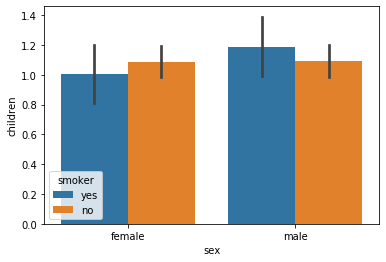

In [41]:
#Q3.h - Distribution of categorical columns (include children)
sns.barplot(x ='sex', y ='children', data = df,hue='smoker')
#sns.catplot(x="sex", y="children", hue="smoker", kind="bar", data=df);

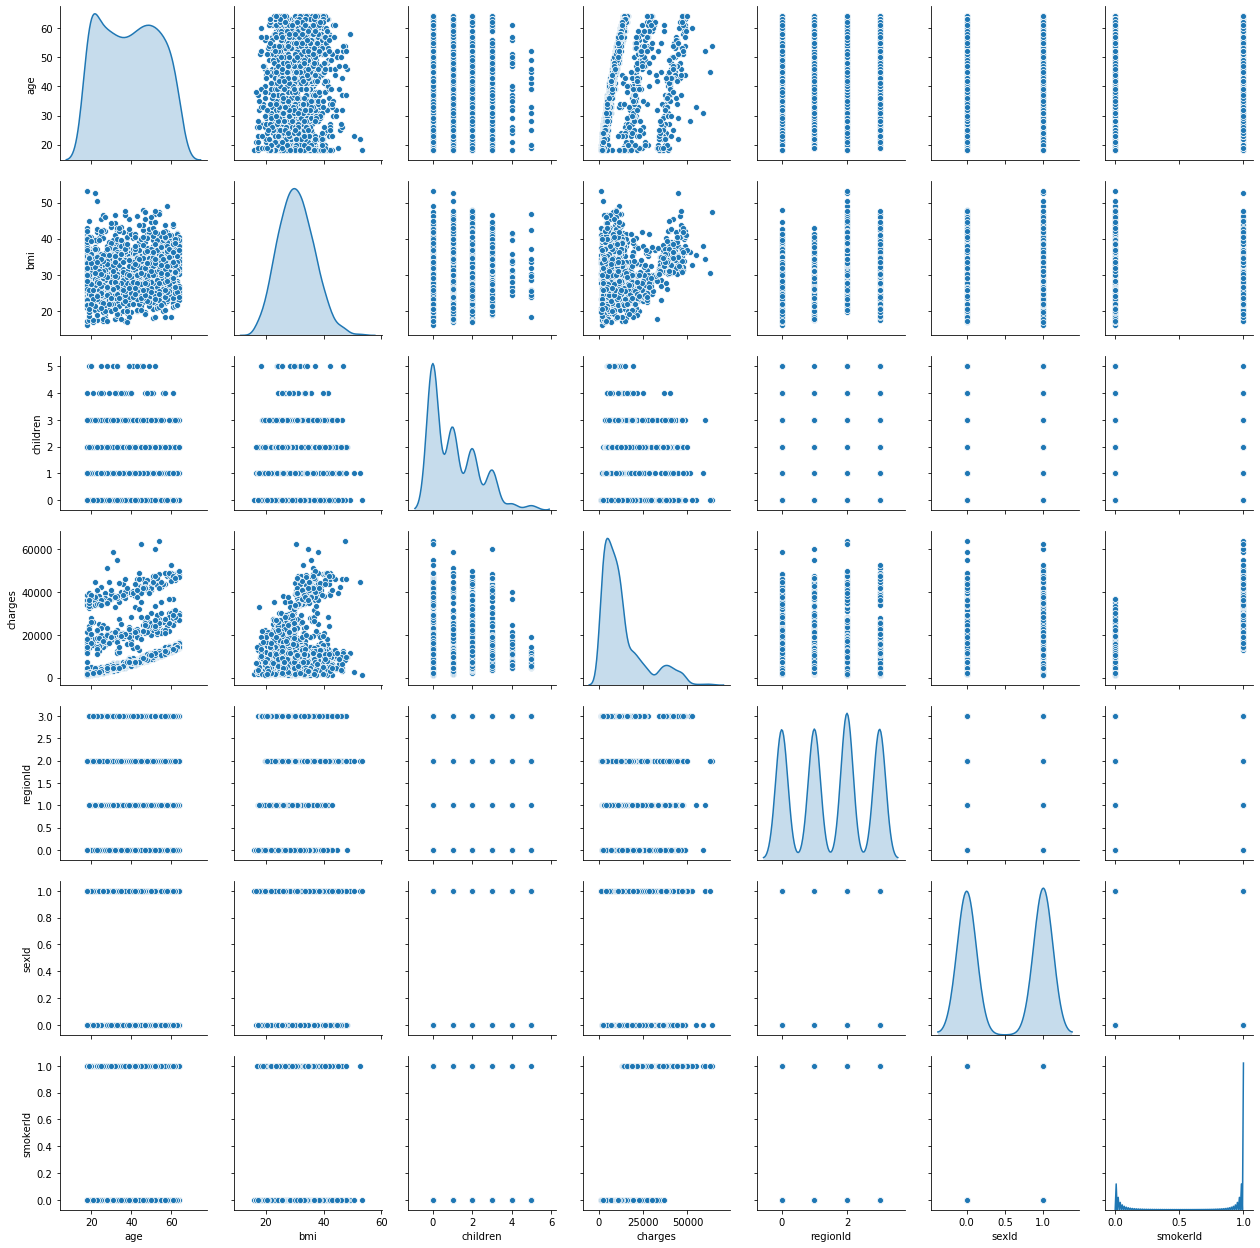

In [42]:
#Q3.i - Pair plot that includes all the columns of the dataframe

labelencoder = LabelEncoder()
df1=df.copy()
df1['regionId'] = labelencoder.fit_transform(df1.region)
df1['sexId'] = labelencoder.fit_transform(df1.sex)
df1['smokerId'] = labelencoder.fit_transform(df1.smoker)
sns.pairplot(df1,diag_kind='kde')

In [45]:
#Q4.a - Do charges of people who smoke differ significantly from the people who don't?
#Define Null Hypothesis and Alternative Hypothesis
print("H0: Null Hypothesis: The charges of smoker and non-smoker are same.")
print("HA: Alternative Hypothesis: The Charges of smoker and non-smoker are significantly different.")

H0: Null Hypothesis: The charges of smoker and non-smoker are same.
HA: Alternative Hypothesis: The Charges of smoker and non-smoker are significantly different.


Shapiro test: smoker stats:
0.9395521879196167 3.6251879276250065e-09


Shapiro test: Non-smoker stats:
0.8728628158569336 1.4455900162299346e-28


Based on shapiro test, smoker and non-smoker samples are NOT normally distributed.  so performing non parametric test 

MannWhitney test - stat=7403.00, p=0.00
7403.0 2.6351167222517853e-130
smoker and nonsmoker are significantly different based on Mannwhitney test P value 

to validate with another method, performing parametric test as well 

T test : stat=46.66, p=0.000
46.664921172723716 8.271435842177219e-283
Since th P-Value is less than 0.05, reject the Null Hyposthesis.
In other words, there is a significant difference between smoker and non-smoker charges


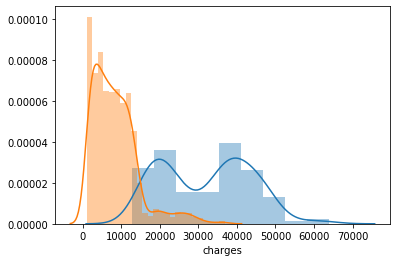

In [46]:
#Step 1: check Data normality

df_smoker=df[df['smoker'].str.contains('yes')]['charges']
stat, p = shapiro(df_smoker)
print('Shapiro test: smoker stats:')
print(stat, p)
print('\n')
df_nonsmoker=df[df['smoker'].str.contains('no')]['charges']
stat, p = shapiro(df_nonsmoker)
print('Shapiro test: Non-smoker stats:')
print(stat, p)
print('\n')
print('Based on shapiro test, smoker and non-smoker samples are NOT normally distributed.  so performing non parametric test \n')

#Step 2: pictorial represntation

sns.distplot(df_smoker)
sns.distplot(df_nonsmoker)

#Step 3: From shapiro test, it seems the data is not normal. So a non-parametric test should be performed.

stat, p = mannwhitneyu(df_smoker, df_nonsmoker)
print('MannWhitney test - stat=%.2f, p=%.2f' % (stat, p))
print(stat,p)
if p > 0.05:
    print('smoker and nonsmoker are same distribution based on Mannwhitney test P value \n')
else:
    print('smoker and nonsmoker are significantly different based on Mannwhitney test P value \n')

#step 4: Parametric test

stat, p = scipy.stats.ttest_ind(df_smoker, df_nonsmoker)
#print(scipy.stats.ttest_ind(df_smoker['charges'], df_nonsmoker['charges']))
print('to validate with another method, performing parametric test as well \n')
print('T test : stat=%.2f, p=%.3f' % (stat, p))
print(stat, p)
print('Since th P-Value is less than 0.05, reject the Null Hyposthesis.\nIn other words, there is a significant difference between smoker and non-smoker charges')

In [47]:
#Q4.b - Does bmi of males differ significantly from that of females?
#Define Null Hypothesis and Alternative Hypothesis
print("H0: Null Hypothesis: BMI of male and female are same.")
print("HA: Alternative Hypothesis: BMI of male and female are significantly different.")

H0: Null Hypothesis: BMI of male and female are same.
HA: Alternative Hypothesis: BMI of male and female are significantly different.


Shapiro test stats of males : stat=0.993, p=0.003
Shapiro test stats of females : stat=0.993, p=0.004
Shapiro test indicates both population are not normally distributed, so we can apply non-parametric test
MannWhitney: stat=212180.00, p=0.051
ttest_ind : stat=1.697, p=0.090
1.696752635752224 0.08997637178984932
Based on statistical evidence, BMI of males are NOT significantly different from BMI of females


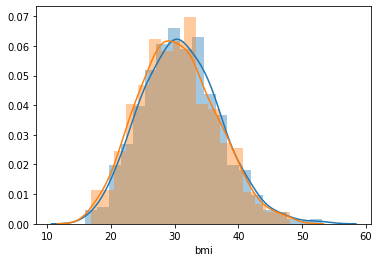

In [48]:
#Map numerical values to categorical column to ferform further anaysis.
df['Gender'] = df['sex'].map( {'male':1, 'female':0} )
df[['sex', 'Gender']]

bmi_males = df[df['Gender']==1]['bmi']
bmi_males

bmi_females = df[df['Gender']==0]['bmi']
bmi_females

#Step 1: Shapiro test to find the data normality

stat, p = shapiro(bmi_males)
print('Shapiro test stats of males : stat=%.3f, p=%.3f' % (stat, p))

stat, p = shapiro(bmi_females)
print('Shapiro test stats of females : stat=%.3f, p=%.3f' % (stat, p))

print('Shapiro test indicates both population are not normally distributed, so we can apply non-parametric test')

#Step 2: Pictorial representation
sns.distplot(bmi_males) 
sns.distplot(bmi_females)

#step 3: MannWhitney U test
stat, p = mannwhitneyu(bmi_males, bmi_females)
print('MannWhitney: stat=%.2f, p=%.3f' % (stat, p))
#print(stat,p)

#Step 4: ttest_ind test
stat, p = scipy.stats.ttest_ind(bmi_males, bmi_females)
print('ttest_ind : stat=%.3f, p=%.3f' % (stat, p))
print(stat,p)

print('Based on statistical evidence, BMI of males are NOT significantly different from BMI of females')

In [49]:
#Q4 c. Is the proportion of smokers significantly different in different gender
#Define Null Hypothesis and Alternative Hypothesis
print("H0: Null Hypothesis: the proportion of smokers in different gender are same.")
print("HA: Alternative Hypothesis: The proportion of smokers are significantly different in different gender")

H0: Null Hypothesis: the proportion of smokers in different gender are same.
HA: Alternative Hypothesis: The proportion of smokers are significantly different in different gender


In [50]:
#Step 1 - Create Contingency table to identify the smoker category based on gender
df_smoker_crosstab = pd.crosstab(df['sex'],df['smoker']) 
print(df_smoker_crosstab) 

#Step 2 - Create a dataframe with the array of smoker category counts based on gender.
smoker_proportion_df = pd.DataFrame([[159,517],[115,547]],
                                    index=['Male','Female'],columns=['Smoker','Non Smoker'])
smoker_proportion_df

smoker   no  yes
sex             
female  547  115
male    517  159


,Smoker,Non Smoker
Male,159,517
Female,115,547


In [78]:
#Step 3 - Perform Chi Square test for the categorical columns.

from scipy.stats import chi2_contingency
stat, p, dof, expected = chi2_contingency(smoker_proportion_df)
print('chi square contingency results: stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Proportion of smokers in different gender are NOT significantly different based on chi square test')
else:
    print('Proportion of smokers in different gender are significantly different based on chi square test')

chi square contingency results: stat=7.393, p=0.007
Proportion of smokers in different gender are significantly different based on chi square test


In [52]:
#Q4.d - Is the distribution of bmi across women with no children, one child and two children, the same ?
#Define Null Hypothesis and Alternative Hypothesis
print("H0: Null Hypothesis: The distribution of bmi across women with no children, one child and two children are same.")
print("HA: Alternative Hypothesis: The distribution of bmi across women with no children, one child and two children are different")

H0: Null Hypothesis: The distribution of bmi across women with no children, one child and two children are same.
HA: Alternative Hypothesis: The distribution of bmi across women with no children, one child and two children are different


Shapiro test stats of women_withZero : stat=0.990, p=0.038
Shapiro test stats of women_withOne : stat=0.992, p=0.536
Shapiro test stats of women_withTwo : stat=0.986, p=0.260 

Levene test stats: stat=0.943, p=0.390 

Annova test stat=0.334, p=0.716
Yes, distribution of bmi across women with no children, one child and two children are same 

Kruskal Test stat=0.714, p=0.700
Yes, distribution of bmi across women with no children, one child and two children are same 



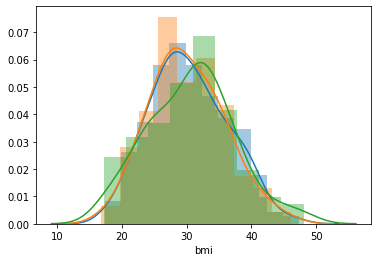

In [53]:
from scipy.stats import levene
# Step1: Check Data normality
women_withZero = df[(df['sex']=='female') & (df['children'] == 0)]['bmi']
stat, p = shapiro(women_withZero)
print('Shapiro test stats of women_withZero : stat=%.3f, p=%.3f' % (stat, p))

women_withOne = df[(df['sex']=='female') & (df['children'] == 1)]['bmi']
stat, p = shapiro(women_withOne)
print('Shapiro test stats of women_withOne : stat=%.3f, p=%.3f' % (stat, p))

women_withTwo = df[(df['sex']=='female') & (df['children'] == 2)]['bmi']
stat, p = shapiro(women_withTwo)
print('Shapiro test stats of women_withTwo : stat=%.3f, p=%.3f \n' % (stat, p))

stat, p = levene(women_withZero,women_withOne,women_withTwo)
print('Levene test stats: stat=%.3f, p=%.3f \n' % (stat, p))

#Step2: Pictorial Representation
sns.distplot(women_withZero, kde=True)
sns.distplot(women_withOne, kde=True)
sns.distplot(women_withTwo, kde=True)

#step3: Annova Test
from scipy.stats import f_oneway
stat, p = f_oneway(women_withZero, women_withOne, women_withTwo)
print('Annova test stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Yes, distribution of bmi across women with no children, one child and two children are same \n')
else:
    print('No, distribution of bmi across women with no children, one child and two children are different')

#Step 4: Kruskal test to support not-normal data
from scipy.stats import kruskal
stat, p = kruskal(women_withZero, women_withOne, women_withTwo)
print('Kruskal Test stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Yes, distribution of bmi across women with no children, one child and two children are same \n')
else:
    print('No, distribution of bmi across women with no children, one child and two children are different')

